# DCT Laboratory — Volume II, Chapter 16
## Enterprise Applications and Integrated Case Studies
**Seed `26216`** · Companion to the chapter and AXIOM Module **AXIOM-16 (Vol. II)**

The capstone. **Seven sector cases Pareto-sorted** on (value uplift, risk
reduction): four efficient, three dominated — Chapter 12's machinery grading
the book's own case studies. The **integrated-methodology scorecard**: four
stages, one weighting, PE/VC crowned at 8.3. And the **final exam battery**:
five of the volume's anchor numbers recomputed from scratch in one place —
duality gap 0, switch optimum 39.6863, $\lambda_0 = 1.0629$, HJB
$V(10) = -5$, and the DRO flip at 0.125. The whole volume, alive in one sheet.
Mirrored in `DCT_V2_Ch16_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26216
CASES = {"MFG":(7.2,5.1),"FIN":(6.5,7.8),"HLT":(4.8,8.5),"ENE":(5.9,6.2),
         "TEC":(9.1,3.4),"GOV":(3.6,7.1),"PEV":(8.3,5.8)}
def dominated(name):
    u,r = CASES[name]
    return any((u2>=u and r2>=r and (u2>u or r2>r)) for n2,(u2,r2) in CASES.items() if n2!=name)
def pareto(): return [n for n in CASES if not dominated(n)]
STAGES = {"MFG":(8,7,9,6),"FIN":(7,8,7,8),"HLT":(6,7,6,9),"ENE":(7,6,7,7),
          "TEC":(9,9,8,6),"GOV":(5,6,5,8),"PEV":(8,9,8,8)}
W = (0.2,0.3,0.3,0.2)
def composite(name): return round(sum(w*s for w,s in zip(W,STAGES[name])),4)
# --- the final exam battery: five anchors, from scratch ---
def anchor_duality():
    primal = min((u-4)**2 for u in np.linspace(0,2,20001))
    lam = 4.0; dual = 2*lam - lam*lam/4
    return round(primal - dual, 4)
def anchor_switch():
    return round(max(3*(6-m)*np.sqrt(4+3*m) for m in range(7)), 4)
def anchor_lambda0():
    return round(2*0.9**6, 4)
def anchor_hjb():
    rho, r = 0.10, 0.05
    return round((np.log(rho)+r/rho-1)/rho + np.log(10)/rho, 4)
def anchor_flip():
    return round((6.8-4.8)/(18-2), 4)

def reference_values():
    comps = {n: composite(n) for n in CASES}
    order = sorted(comps, key=comps.get, reverse=True)
    vals = np.array(list(comps.values()))
    anchors = {"anchor_duality_gap": anchor_duality(), "anchor_switch_J": anchor_switch(),
               "anchor_lambda0": anchor_lambda0(), "anchor_V10_hjb": anchor_hjb(),
               "anchor_flip_delta": anchor_flip()}
    expect = {"anchor_duality_gap":0.0,"anchor_switch_J":39.6863,"anchor_lambda0":1.0629,
              "anchor_V10_hjb":-5.0,"anchor_flip_delta":0.125}
    all_ok = int(all(abs(anchors[k]-expect[k])<5e-4 for k in anchors))
    return {
        "n_cases": len(CASES), "n_pareto": len(pareto()), "n_dominated": len(CASES)-len(pareto()),
        "top_composite": comps[order[0]], "top_is_PEV": int(order[0]=="PEV"),
        "second_composite": comps[order[1]],
        "mean_composite": round(float(vals.mean()),4),
        "std_composite": round(float(vals.std(ddof=0)),4),
        **anchors, "all_anchors_pass": all_ok,
    }
if __name__ == "__main__":
    print("pareto:", pareto(), " composites:", {n:composite(n) for n in CASES})
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

pareto: ['FIN', 'HLT', 'TEC', 'PEV']  composites: {'MFG': 7.6, 'FIN': 7.5, 'HLT': 6.9, 'ENE': 6.7, 'TEC': 8.1, 'GOV': 5.9, 'PEV': 8.3}
n_cases              7
n_pareto             4
n_dominated          3
top_composite        8.3
top_is_PEV           1
second_composite     8.1
mean_composite       7.2857
std_composite        0.7791
anchor_duality_gap   0.0
anchor_switch_J      39.6863
anchor_lambda0       1.0629
anchor_V10_hjb       -5.0
anchor_flip_delta    0.125
all_anchors_pass     1


## Panel 1 — Cross-case comparative analysis, Pareto-graded
Seven transformations scored on what boards actually trade: value uplift
against risk reduction. Chapter 12's dominance test does the first cut:
Manufacturing falls to PE/VC, Energy to Financial Services, Government to
Healthcare — **three dominated, four efficient** {FIN, HLT, TEC, PEV}. The
capstone's quiet point: even the book's own case studies obey the book — no
sector wins both axes, and the surviving four ARE the strategy conversation.

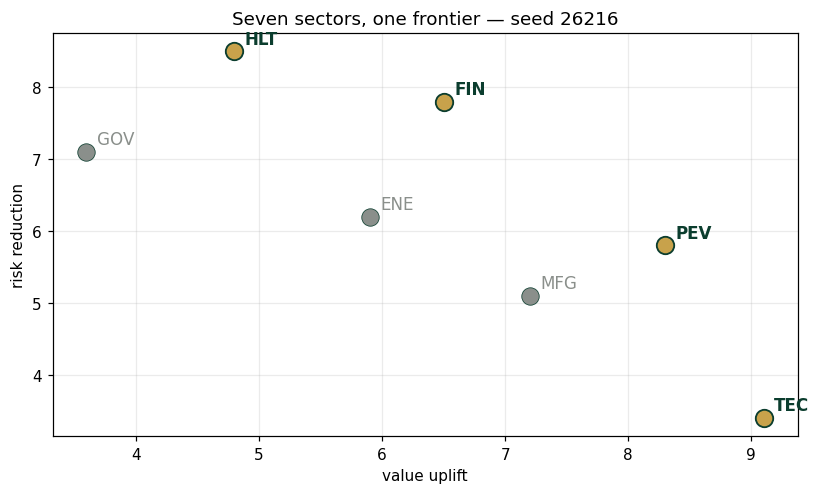

efficient: ['FIN', 'HLT', 'TEC', 'PEV']   dominated: ['MFG', 'ENE', 'GOV']


In [2]:
fig, ax = plt.subplots(figsize=(7.6,4.6))
for n,(u,r) in CASES.items():
    on = n in pareto()
    ax.scatter([u],[r], s=130, c="#C8A24B" if on else "#8A8F8B", zorder=5,
               edgecolors="#0B3D2E", linewidths=1.2 if on else 0.5)
    ax.annotate(n, (u,r), textcoords="offset points", xytext=(7,5), fontsize=11,
                color="#0B3D2E" if on else "#8A8F8B", fontweight="bold" if on else "normal")
ax.set(xlabel="value uplift", ylabel="risk reduction", title="Seven sectors, one frontier — seed 26216")
ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"efficient: {pareto()}   dominated: {[n for n in CASES if dominated(n)]}")

## Panel 2 — The integrated methodology, scored
Each case graded 1–10 on the methodology's four stages — Diagnose, Design,
Execute, Sustain — composited with weights $(0.2, 0.3, 0.3, 0.2)$ (design and
execution carry the middle). The table crowns **PE/VC at 8.3** with Technology
at 8.1; Government's 5.9 marks where the methodology met the hardest
institutional friction. Cross-case mean 7.29, spread 0.78: the methodology
transfers, and the residual variation is the Lessons Learned section's
subject.

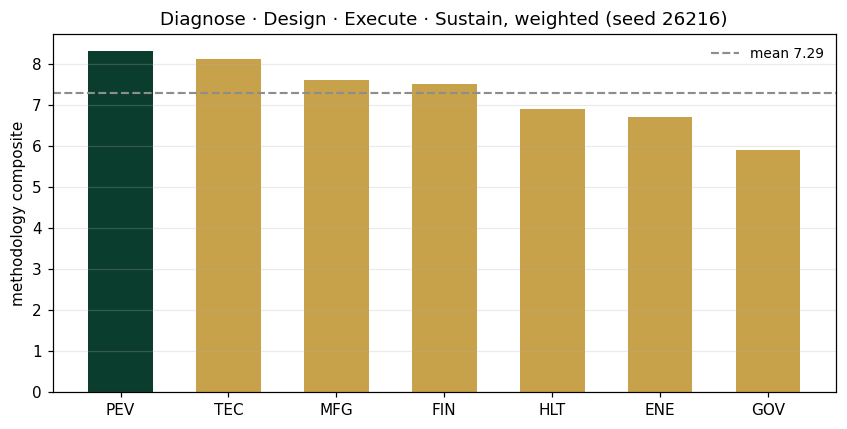

  PEV: 8.3
  TEC: 8.1
  MFG: 7.6
  FIN: 7.5
  HLT: 6.9
  ENE: 6.7
  GOV: 5.9


In [3]:
comps = {n: composite(n) for n in CASES}
order = sorted(comps, key=comps.get, reverse=True)
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.bar(order, [comps[n] for n in order],
       color=["#0B3D2E" if n==order[0] else "#C8A24B" for n in order], width=.6)
ax.axhline(np.mean(list(comps.values())), c="#8A8F8B", ls="--", lw=1.4, label=f"mean {np.mean(list(comps.values())):.2f}")
ax.set(ylabel="methodology composite", title="Diagnose · Design · Execute · Sustain, weighted (seed 26216)")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25, axis="y"); plt.tight_layout(); plt.show()
for n in order: print(f"  {n}: {comps[n]}")

## Panel 3 — The final exam battery
Five anchors from five arcs, recomputed from scratch — no imports from earlier
labs, just the mathematics: the **duality gap** (Ch. 3) at 0; the **switch
optimum** (Chs. 5 and 7, thrice derived) at 39.6863; **Pontryagin's**
$\lambda_0 = 2 \cdot 0.9^6 = 1.0629$ (Ch. 6); the **HJB value**
$V(10) = -5$ exactly (Ch. 8); the **DRO flip** at $\delta^* = 0.125$
(Ch. 11). Five arcs, five decimals, one verdict: `all_anchors_pass = 1`. The
course's oldest habit — cross-checking everything against exact small cases —
applied, at the very end, to itself.

In [4]:
battery = [("duality gap (Ch.3)", anchor_duality(), 0.0),
           ("switch optimum (Chs.5/7)", anchor_switch(), 39.6863),
           ("Pontryagin lambda_0 (Ch.6)", anchor_lambda0(), 1.0629),
           ("HJB V(10) (Ch.8)", anchor_hjb(), -5.0),
           ("DRO flip delta* (Ch.11)", anchor_flip(), 0.125)]
print("anchor                          recomputed   expected")
ok = True
for name, got, exp in battery:
    ok &= abs(got-exp) < 5e-4
    print(f"{name:30s} {got:10.4f} {exp:10.4f}   {'OK' if abs(got-exp)<5e-4 else 'FAIL'}")
print(f"\nall_anchors_pass = {int(ok)} — the volume's spine, verified end to end.")

anchor                          recomputed   expected
duality gap (Ch.3)                 0.0000     0.0000   OK
switch optimum (Chs.5/7)          39.6863    39.6863   OK
Pontryagin lambda_0 (Ch.6)         1.0629     1.0629   OK
HJB V(10) (Ch.8)                  -5.0000    -5.0000   OK
DRO flip delta* (Ch.11)            0.1250     0.1250   OK

all_anchors_pass = 1 — the volume's spine, verified end to end.


## Validation — agrees with `DCT_V2_Ch16_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"n_cases":7,"n_pareto":4,"n_dominated":3,"top_composite":8.3,"top_is_PEV":1,
 "second_composite":8.1,"mean_composite":7.2857,"std_composite":0.7791,
 "anchor_duality_gap":0.0,"anchor_switch_J":39.6863,"anchor_lambda0":1.0629,
 "anchor_V10_hjb":-5.0,"anchor_flip_delta":0.125,"all_anchors_pass":1}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
print("\nAll checkpoints agree — seed 26216. Volume II complete.")

PASS  n_cases              7
PASS  n_pareto             4
PASS  n_dominated          3
PASS  top_composite        8.3
PASS  top_is_PEV           1
PASS  second_composite     8.1
PASS  mean_composite       7.2857
PASS  std_composite        0.7791
PASS  anchor_duality_gap   0.0
PASS  anchor_switch_J      39.6863
PASS  anchor_lambda0       1.0629
PASS  anchor_V10_hjb       -5.0
PASS  anchor_flip_delta    0.125
PASS  all_anchors_pass     1

All checkpoints agree — seed 26216. Volume II complete.


**The course closes here.** Exercises 16.1–16.13 send each sector case back through the full methodology; AXIOM-16's capstone board lets you score your own transformation on the four stages and see where it lands on the frontier. Solutions: IM Vol. II, Ch. 16 — and thank you for taking the course.